Exploración para limpieza

Este notebook analiza la calidad del **dataset base** producido por `loader.py` con el objetivo de tomar decisiones fundadas sobre la limpieza estructural que se implementará en `cleaner.py`.

El análisis sigue este orden:
1. Visión global de nulos
2. Detección de errores de registro en vitales
3. Variables categóricas (`gender`, `race`, `arrival_transport`)
4. Caso especial: `pain` como campo de texto libre
5. Verificación de targets (`acuity`) y variables auxiliares


## 1. Carga del dataset base

Se carga desde caché (`dataset_base.parquet`) sin ninguna transformación.

In [1]:
from triaje_ia.config import DATA_RAW, DATA_INTERIM, DATA_PROCESSED, MODELS_DIR, FIGURES_DIR
from triaje_ia.data.loader import cargar_dataset_base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = cargar_dataset_base(forzar=False)
print(f"Shape: {df.shape}")
print(f"Columnas:\n{list(df.columns)}")

2026-03-07 17:29:14.768 | WARNING  | triaje_ia.data.loader:cargar_dataset_base:417 - Cargando desde caché: C:\Users\CARLOS\triaje-ia-tfg\data\interim\dataset_base.parquet. Si cambiaste parámetros del pipeline, usa forzar=True.
2026-03-07 17:29:15.214 | SUCCESS  | triaje_ia.data.loader:cargar_dataset_base:422 - Cargado: 425,087 filas | 53 columnas


Shape: (425087, 53)
Columnas:
['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'gender', 'race', 'arrival_transport', 'disposition', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint', 'age', 'n_medicamentos', 'medicacion_raw', 'med_estatina', 'med_antiagregante', 'med_anticoagulante', 'med_betabloqueante', 'med_ieca_ara2', 'med_calcioantagonista', 'med_nitrato', 'med_alfa_bloqueante', 'med_broncodilatador', 'med_corticoide_inhal', 'med_insulina', 'med_antidiabetico_oral', 'med_tiroides', 'med_benzodiacepina', 'med_opioide', 'med_antidepresivo', 'med_anticonvulsivo', 'med_antipsicotico', 'med_estimulante_snc', 'med_sedante_hipnotico', 'med_aine', 'med_analgesico_suave', 'med_corticoide_sist', 'med_inmunosupresor', 'med_diuretico', 'med_antiacido', 'med_laxante', 'med_antiemetico', 'med_antihistaminico', 'med_antibiotico', 'label_disposition', 'ccs_category']


## 2. Análisis de valores nulos

El primer paso es cuantificar los valores faltantes por columna. Es clave distinguir entre tres tipos de nulos:

- **Nulos en el target** (`acuity`): Las filas afectadas se eliminan.
- **Nulos en vitales** (4–6%): ausencia real de medición en triaje — paciente inconsciente, dato no recogido, etc. Se imputan con mediana **dentro del Pipeline de sklearn**, nunca antes del `train_test_split`, para evitar data leakage.
- **Nulos residuales** (`age`, `chiefcomplaint`, `ccs_category`): volumen muy pequeño, tratamiento específico por columna.

In [2]:
# Nulos por columna
nulos = df.isna().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen = pd.DataFrame({
    "n_nulos": nulos,
    "pct": nulos_pct
}).query("n_nulos > 0").sort_values("pct", ascending=False)

resumen

,n_nulos,pct
hadm_id,222071,52.24
temperature,23415,5.51
o2sat,20596,4.85
resprate,20353,4.79
dbp,19091,4.49
sbp,18291,4.30
heartrate,17090,4.02
pain,12933,3.04
acuity,6987,1.64
ccs_category,1108,0.26


## 3. Estadísticas descriptivas de vitales

Se inspeccionan los estadísticos básicos de cada vital para detectar valores fisiológicamente imposibles. Los máximos absurdos —temperatura de 986°F, presión diastólica de 661 mmHg— no son outliers clínicos sino **errores de transcripción**

Estos valores se convertirán a `NaN` en `cleaner.py`.

In [3]:
vitales = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp", "pain"]

df[vitales].describe().round(2)

,temperature,heartrate,resprate,o2sat,sbp,dbp
count,401672.00,407997.00,404734.00,404491.00,406796.00,405996.00
mean,98.02,85.08,17.57,98.47,135.40,81.26
std,4.01,18.04,5.49,17.04,240.96,1057.22
min,0.10,1.00,0.00,0.00,1.00,0.00
25%,97.50,72.00,16.00,97.00,120.00,68.00
50%,98.00,84.00,18.00,99.00,133.00,77.00
75%,98.60,96.00,18.00,100.00,148.00,87.00
max,986.00,1228.00,1820.00,9322.00,151103.00,661672.00


## 4. Cuantificación de valores fuera de rango fisiológico

Se definen umbrales clínicamente razonables y fundados en base a entidades de salud reconocidas para cada vital y se cuenta cuántos registros los superan. Los umbrales están documentados en `cleaner.py`

| Vital | Rango válido |
|---|---|
| temperature | 85–107 °F | 
| heartrate | 20–300 lpm | 
| resprate | 4–60 rpm | 
| o2sat | 50–100% | 
| sbp | 40–300 mmHg | 
| dbp | 20–200 mmHg | 

Los porcentajes fuera de rango son todos inferiores al 0.15%, lo que confirma que son errores puntuales y no un problema sistemático.

In [13]:
rangos = {
    "temperature": (85.0, 107.0), #F
    "heartrate":   (20.0, 300.0),
    "resprate":    (4.0, 60.0),
    "o2sat":       (50.0, 100.0),
    "sbp":         (40.0, 300.0),
    "dbp":         (20.0, 200.0)
}

for col, (vmin, vmax) in rangos.items():
    total = df[col].notna().sum()
    fuera = ((df[col] < vmin) | (df[col] > vmax)).sum()
    pct = fuera / total * 100
    print(f"{col:<15} fuera de [{vmin}, {vmax}]: {fuera:,} ({pct:.2f}%)")

temperature     fuera de [85.0, 107.0]: 540 (0.13%)
heartrate       fuera de [20.0, 300.0]: 29 (0.01%)
resprate        fuera de [4.0, 60.0]: 58 (0.01%)
o2sat           fuera de [50.0, 100.0]: 139 (0.03%)
sbp             fuera de [40.0, 300.0]: 203 (0.05%)
dbp             fuera de [20.0, 200.0]: 593 (0.15%)


## 5. Visualización preliminar de distribuciones

Primera inspección visual de los vitales filtrados al rango válido. Se comprueba que las distribuciones tienen forma esperada y que las medianas son coherentes.

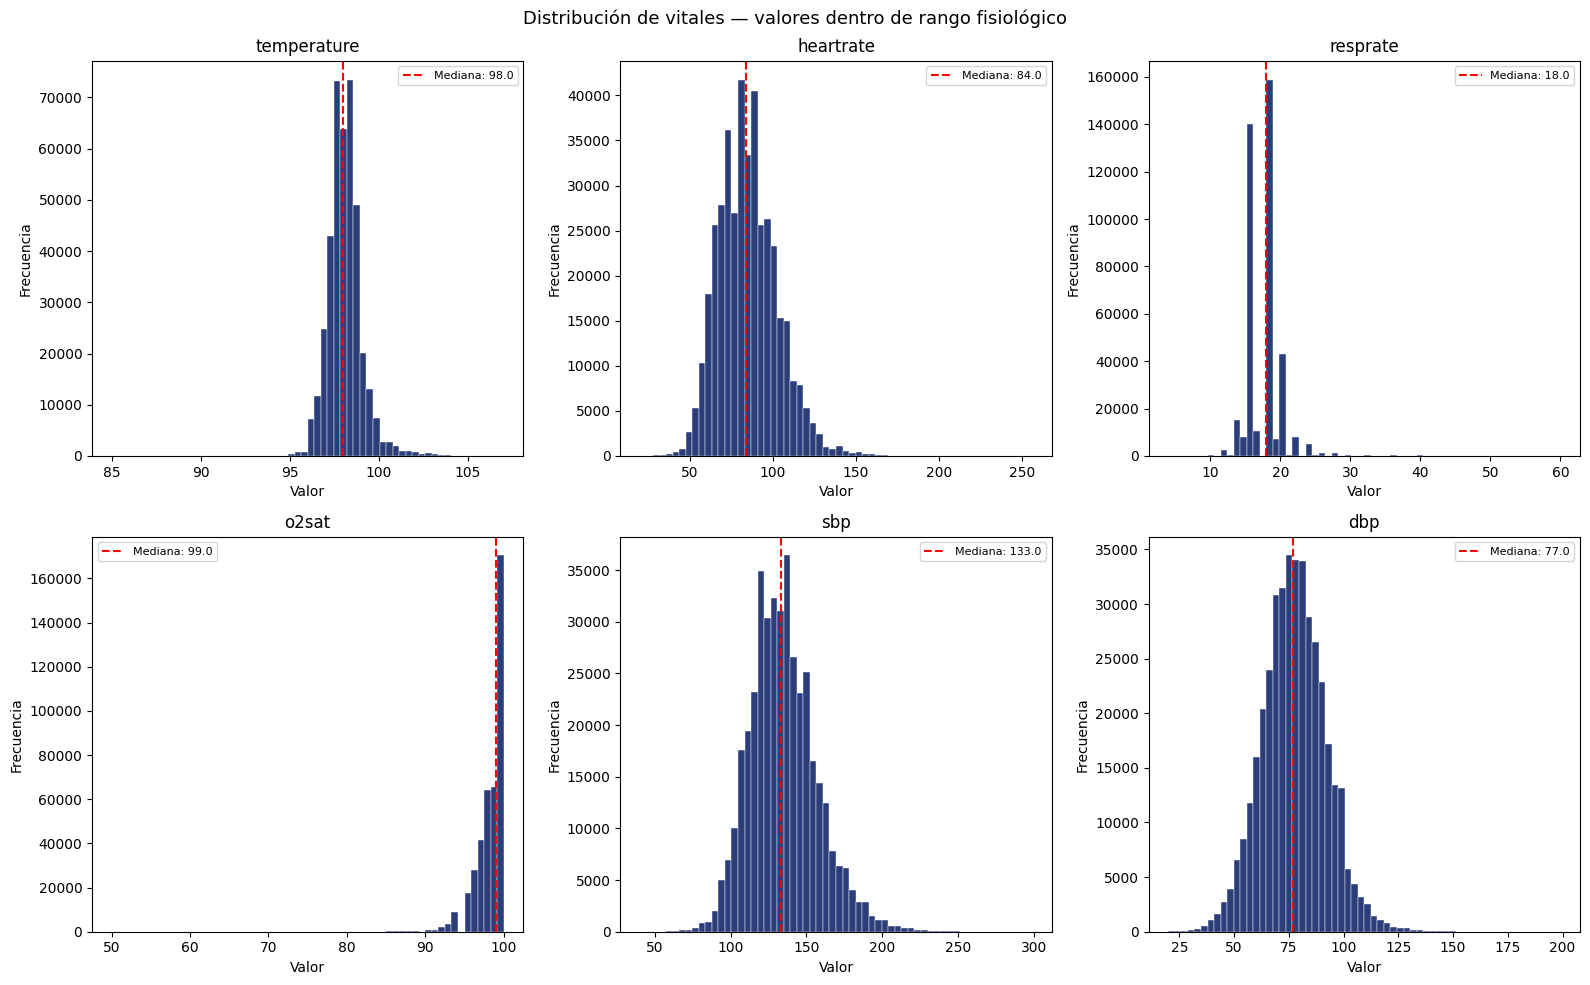

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribución de vitales — valores dentro de rango fisiológico", fontsize=13)

for ax, (col, (vmin, vmax)) in zip(axes.flatten(), rangos.items()):
    datos = df[col].dropna()
    datos_limpios = datos[(datos >= vmin) & (datos <= vmax)]
    
    ax.hist(datos_limpios, bins=60, color="#2C3E7A", edgecolor="white", linewidth=0.3)
    ax.axvline(datos_limpios.median(), color="red", linestyle="--", linewidth=1.5,
               label=f"Mediana: {datos_limpios.median():.1f}")
    ax.set_title(col)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Distribuciones validadas — panel definitivo

Panel de validación post-limpieza con información estadística completa. Para cada vital se muestran:

- **Mediana** (rojo): valor central representativo
- **P5 / P95** (naranja / verde): rango donde se concentra el 90% de los datos
- **Límites fisiológicos** (negro punteado): bordes del rango definido en `rangos`
- **Zona sombreada roja**: región inválida — debe estar vacía tras la limpieza

Si las barras del histograma no alcanzan los límites negros, la limpieza es correcta. El recuadro superior derecho muestra el tamaño efectivo de cada vital tras eliminar nulos y valores imposibles.

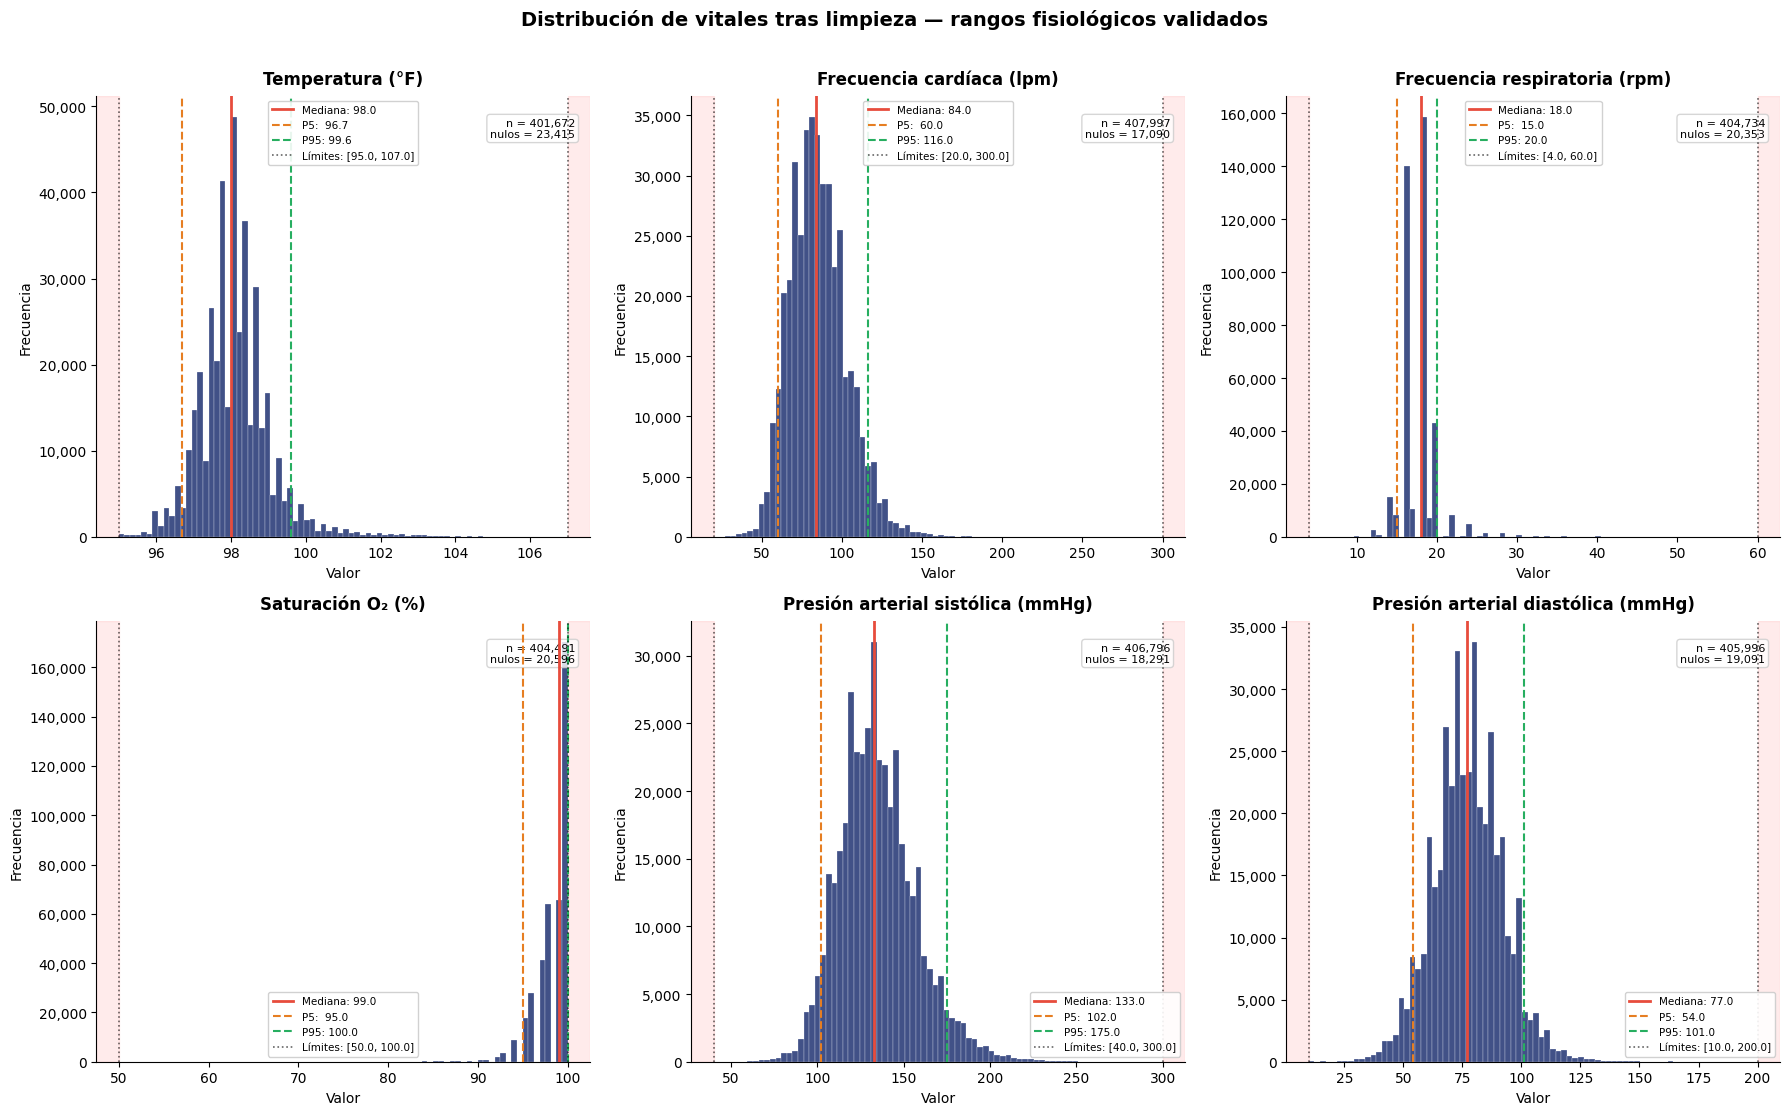

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "Distribución de vitales tras limpieza — rangos fisiológicos validados",
    fontsize=14, fontweight="bold", y=1.01
)

rangos = {
    "temperature": (95.0, 107.0),
    "heartrate":   (20.0, 300.0),
    "resprate":    (4.0,  60.0),
    "o2sat":       (50.0, 100.0),
    "sbp":         (40.0, 300.0),
    "dbp":         (10.0, 200.0),
}

titulos = {
    "temperature": "Temperatura (°F)",
    "heartrate":   "Frecuencia cardíaca (lpm)",
    "resprate":    "Frecuencia respiratoria (rpm)",
    "o2sat":       "Saturación O₂ (%)",
    "sbp":         "Presión arterial sistólica (mmHg)",
    "dbp":         "Presión arterial diastólica (mmHg)",
}

for ax, (col, (vmin, vmax)) in zip(axes.flatten(), rangos.items()):
    datos = df[col].dropna()
    mediana = datos.median()
    p5  = datos.quantile(0.05)
    p95 = datos.quantile(0.95)

    # Ajustar xlim al rango real con margen
    margen = (vmax - vmin) * 0.05
    ax.set_xlim(vmin - margen, vmax + margen)

    # Histograma
    ax.hist(datos, bins=80, range=(vmin, vmax),
            color="#2C3E7A", edgecolor="white", linewidth=0.2, alpha=0.9)

    # Mediana
    ax.axvline(mediana, color="#E74C3C", linestyle="-", linewidth=2,
               label=f"Mediana: {mediana:.1f}", zorder=5)

    # P5 - P95
    ax.axvline(p5,  color="#E67E22", linestyle="--", linewidth=1.5,
               label=f"P5:  {p5:.1f}", zorder=5)
    ax.axvline(p95, color="#27AE60", linestyle="--", linewidth=1.5,
               label=f"P95: {p95:.1f}", zorder=5)

    # Límites fisiológicos
    ax.axvline(vmin, color="black", linestyle=":", linewidth=1.2, alpha=0.6,
               label=f"Límites: [{vmin}, {vmax}]", zorder=5)
    ax.axvline(vmax, color="black", linestyle=":", linewidth=1.2, alpha=0.6,
               zorder=5)

    # Sombrear fuera de rango (solo si hay margen)
    ax.axvspan(vmin - margen, vmin, color="red", alpha=0.08)
    ax.axvspan(vmax, vmax + margen, color="red", alpha=0.08)

    # Estadísticas en el gráfico
    ax.text(0.97, 0.95,
            f"n = {len(datos):,}\nnulos = {df[col].isna().sum():,}",
            transform=ax.transAxes, fontsize=8, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#CCCCCC", alpha=0.8))

    ax.set_title(titulos[col], fontweight="bold", pad=8)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=7.5, frameon=True, framealpha=0.9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{int(x):,}"
    ))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Variables categóricas

Se inspeccionan las tres variables categóricas disponibles en el minuto 0 del triaje:

- **`gender`**: binaria F/M. Se espera limpia y sin nulos.
- **`arrival_transport`**: medio de llegada. `UNKNOWN` es una categoría válida (dato no recogido), no un error — se mantiene como categoría propia.
- **`race`**: alta granularidad. MIMIC recoge la etnia con mucho detalle, generando 33 categorías distintas con distribución muy desigual. Requiere agrupación.

In [15]:
for col in ["gender", "race", "arrival_transport"]:
    print(f"\n=== {col.upper()} ===")
    print(df[col].value_counts(dropna=False))


=== GENDER ===
gender
F    229898
M    195189
Name: count, dtype: int64

=== RACE ===
race
WHITE                                        228123
BLACK/AFRICAN AMERICAN                        76798
OTHER                                         20752
HISPANIC/LATINO - PUERTO RICAN                14036
WHITE - OTHER EUROPEAN                         8992
HISPANIC/LATINO - DOMINICAN                    8330
BLACK/CAPE VERDEAN                             7638
ASIAN - CHINESE                                7348
ASIAN                                          7294
UNKNOWN                                        7083
WHITE - RUSSIAN                                6091
BLACK/AFRICAN                                  4887
BLACK/CARIBBEAN ISLAND                         3675
HISPANIC OR LATINO                             3141
HISPANIC/LATINO - GUATEMALAN                   2356
ASIAN - ASIAN INDIAN                           1567
ASIAN - SOUTH EAST ASIAN                       1533
HISPANIC/LATINO - SALVAD

### 7.1 Granularidad de `race`

Se cuantifica la representación de cada categoría. Las 22 categorías con menos de 5.000 registros concentran el 7.7% del total — demasiado poco para que un modelo aprenda patrones robustos de forma independiente.

La solución estándar en investigación clínica con datos MIMIC es agrupar en los grandes grupos étnicos reconocidos: WHITE, BLACK, HISPANIC, ASIAN, OTHER, UNKNOWN.

> **Nota importante**: `race` es una **variable de auditoría de sesgos**, no una feature de entrenamiento. Se incluye en el dataset limpio para analizar si el modelo rinde de forma distinta entre grupos, pero se excluirá de `X` en la fase de modelado.

In [16]:
# Ver cuántas categorías tienen menos de 5000 registros
race_counts = df["race"].value_counts(dropna=False)
print(f"Categorías totales: {race_counts.shape[0]}")
print(f"Con >= 5000 registros: {(race_counts >= 5000).sum()}")
print(f"Con < 5000 registros:  {(race_counts < 5000).sum()}")
print(f"\nRegistros en categorías < 5000: {race_counts[race_counts < 5000].sum():,} ({race_counts[race_counts < 5000].sum()/len(df)*100:.1f}%)")

Categorías totales: 33
Con >= 5000 registros: 11
Con < 5000 registros:  22

Registros en categorías < 5000: 32,602 (7.7%)


### 7.2 Agrupación de `race` en 6 categorías

Se aplica el mapeo de 33 → 6 categorías. La verificación de **0 nulos** tras el mapeo confirma que todos los valores originales tienen correspondencia en el diccionario. Este mismo diccionario `RACE_MAP` se implementa como constante en `cleaner.py`.

In [8]:
race_map = {
    # WHITE
    "WHITE":                                      "WHITE",
    "WHITE - OTHER EUROPEAN":                     "WHITE",
    "WHITE - RUSSIAN":                            "WHITE",
    "WHITE - BRAZILIAN":                          "WHITE",
    "WHITE - EASTERN EUROPEAN":                   "WHITE",
    "PORTUGUESE":                                 "WHITE",

    # BLACK
    "BLACK/AFRICAN AMERICAN":                     "BLACK",
    "BLACK/CAPE VERDEAN":                         "BLACK",
    "BLACK/AFRICAN":                              "BLACK",
    "BLACK/CARIBBEAN ISLAND":                     "BLACK",

    # HISPANIC
    "HISPANIC/LATINO - PUERTO RICAN":             "HISPANIC",
    "HISPANIC/LATINO - DOMINICAN":                "HISPANIC",
    "HISPANIC OR LATINO":                         "HISPANIC",
    "HISPANIC/LATINO - GUATEMALAN":               "HISPANIC",
    "HISPANIC/LATINO - SALVADORAN":               "HISPANIC",
    "HISPANIC/LATINO - COLUMBIAN":                "HISPANIC",
    "HISPANIC/LATINO - MEXICAN":                  "HISPANIC",
    "HISPANIC/LATINO - HONDURAN":                 "HISPANIC",
    "HISPANIC/LATINO - CUBAN":                    "HISPANIC",
    "HISPANIC/LATINO - CENTRAL AMERICAN":         "HISPANIC",
    "SOUTH AMERICAN":                             "HISPANIC",

    # ASIAN
    "ASIAN":                                      "ASIAN",
    "ASIAN - CHINESE":                            "ASIAN",
    "ASIAN - ASIAN INDIAN":                       "ASIAN",
    "ASIAN - SOUTH EAST ASIAN":                   "ASIAN",
    "ASIAN - KOREAN":                             "ASIAN",

    # OTHER
    "OTHER":                                      "OTHER",
    "AMERICAN INDIAN/ALASKA NATIVE":              "OTHER",
    "NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER":  "OTHER",
    "MULTIPLE RACE/ETHNICITY":                    "OTHER",

    # UNKNOWN
    "UNKNOWN":                                    "UNKNOWN",
    "PATIENT DECLINED TO ANSWER":                 "UNKNOWN",
    "UNABLE TO OBTAIN":                           "UNKNOWN",
}

df["race_grouped"] = df["race"].map(race_map)

print(df["race_grouped"].value_counts(dropna=False))
print(f"\nNulos tras mapeo: {df['race_grouped'].isna().sum()}")

race_grouped
WHITE       247459
BLACK        92998
HISPANIC     35574
OTHER        22577
ASIAN        18528
UNKNOWN       7951
Name: count, dtype: int64

Nulos tras mapeo: 0


## 8. Variable `pain` — campo de texto libre

`pain` es el campo más problemático del dataset. En teoría debería contener un entero del 0 al 10, pero en la práctica los enfermeros escribían texto libre durante el triaje: *"feels like shit"*, *"critical"*, *"unable to assess"*, valores de temperatura (98.6), rangos ("6-9"), frases en español (*"mucho"*)...

Con **848 valores únicos distintos**, la estrategia de limpieza debe ser conservadora: solo se recuperan los valores directamente convertibles a `float` en rango [0, 10]. Cualquier texto no convertible → `NaN`.

In [10]:
print("=== PAIN ===")
print(df["pain"].value_counts(dropna=False).sort_index())
print(f"\nValores únicos: {sorted(df['pain'].dropna().unique())}")

=== PAIN ===
pain
  6-9                 1
 0                   11
 10                   4
 4                    1
 6                    2
                  ...  
yes                   1
yes - R arm           1
yes everywhere        1
yes.                  1
None              12933
Name: count, Length: 848, dtype: int64

Valores únicos: ['  6-9', ' 0', ' 10', ' 4', ' 6', ' 67', ' 7', ' 8', ' a little', ' c', '" alittle"', '"10"', '"10+"', '"10++"', '"100"', '"1000"', '"11"', '"110"', '"12"', '"13"', '"14"', '"15"', '"20"', '"200"', '"22"', '"30"', '"50"', '"60"', '">10"', '"A LITTLE"', '"Alot"', '"BAD"', '"I dont do the pain scale"', '"I dont feel pain I feel more discomfort than anything" ', '"I dont know I dont know how to do scales"', '"I love you all" ', '"Not as good as id like it to be"', '"Pain"', '"Too much"', '"a little bit."', '"a little more"', '"a little"', '"a lot of pain"', '"a lot"', '"alittle"', '"all over"', '"alot"', '"annoying"', '"annoying" ', '"bad"', '"badly"', '"b

### 8.1 Parseo de `pain`

La función `_parsear_pain` intenta convertir directamente el valor a `float`. Si la conversión falla (`ValueError`) o el resultado está fuera de [0, 10] → `NaN`. Se recuperan los valores numéricos con decimales redondeándolos al entero más cercano.

Los NaN resultantes se imputarán con mediana en el Pipeline de sklearn.

In [17]:
import re

def _parsear_pain(val) -> float:
    if pd.isna(val):
        return np.nan
    
    # Limpiar comillas y espacios
    val = str(val).strip().strip('"').strip("'")
    
    # Intentar conversión directa
    try:
        num = float(val)
        if 0 <= num <= 10:
            return round(num)
        return np.nan
    except ValueError:
        return np.nan

df["pain_parsed"] = df["pain"].apply(parsear_pain)

total = df["pain"].notna().sum()
recuperados = df["pain_parsed"].notna().sum()
originales_nulos = df["pain"].isna().sum()

print(f"Pain original — con valor:    {total:,}")
print(f"Pain parseado — recuperados:  {recuperados:,}")
print(f"Pain parseado — NaN total:    {df['pain_parsed'].isna().sum():,}")
print(f"  de los cuales eran ya NaN:  {originales_nulos:,}")
print(f"  perdidos en el parseo:      {total - recuperados:,} ({(total-recuperados)/total*100:.1f}%)")
print(f"\nDistribución pain_parsed:")
print(df["pain_parsed"].value_counts().sort_index())

Pain original — con valor:    412,154
Pain parseado — recuperados:  386,911
Pain parseado — NaN total:    38,176
  de los cuales eran ya NaN:  12,933
  perdidos en el parseo:      25,243 (6.1%)

Distribución pain_parsed:
pain_parsed
0.000     140856
0.300          1
0.500         36
1.000       5981
1.200          1
1.500         23
2.000      14012
2.500          7
3.000      16257
3.500         12
4.000      19835
4.400          1
4.500         17
5.000      29384
5.500          6
5.800          1
6.000      25375
6.500         38
6.830          1
7.000      31575
7.200          2
7.235          1
7.500         76
7.600          1
8.000      41883
8.200          1
8.400          1
8.500        105
8.590          1
8.600          2
8.700          2
8.900          1
9.000      20254
9.400          1
9.500        100
9.700          1
9.750          2
9.900          1
10.000     41057
Name: count, dtype: int64


## 9. Targets y variables auxiliares

Verificación final de las variables más críticas del dataset:

- **`acuity`** (target principal): los 6.987 nulos (1.64%) se **eliminan** en `cleaner.py` — no se imputan porque son el objetivo del modelo.
- **`ccs_category`**: 1.108 nulos (0.26%) corresponden a códigos ICD sin match en las tablas CCS. Se mantienen como `NaN` para que el Pipeline decida cómo tratarlos.
- **`age`**: 76 nulos residuales (~0.02%), se imputarán con mediana en el Pipeline. No hay menores de 18 años — MIMIC-IV-ED solo incluye pacientes adultos, lo que simplifica el preprocesamiento demográfico.

In [12]:
print("=== ACUITY ===")
print(df["acuity"].value_counts(dropna=False).sort_index())

print("\n=== CCS_CATEGORY (top 10 + nulos) ===")
print(f"Nulos: {df['ccs_category'].isna().sum():,}")
print(f"Categorías únicas: {df['ccs_category'].nunique()}")
print(df["ccs_category"].value_counts().head(10))

print("\n=== AGE ===")
print(df["age"].describe())
print(f"Menores de 18: {(df['age'] < 18).sum():,}")

=== ACUITY ===
acuity
1.0     24019
2.0    139411
3.0    225066
4.0     28504
5.0      1100
NaN      6987
Name: count, dtype: int64

=== CCS_CATEGORY (top 10 + nulos) ===
Nulos: 1,108
Categorías únicas: 246
ccs_category
251    32056
102    24199
205    14809
259    11445
133    11212
84     10614
211    10342
660    10187
244     9386
197     9191
Name: count, dtype: Int64

=== AGE ===
count     425011.0
mean     52.864493
std      20.619906
min           18.0
25%           35.0
50%           53.0
75%           69.0
max          103.0
Name: age, dtype: Float64
Menores de 18: 0
